In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 

import analysis_utils
sys.path.append("../")

import checkpoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
cp = checkpoint.CheckPoint("../models/MLC_d200kbasestudy3_nep20_best.pt", device=DEVICE)
_, val = cp.load_dataloaders("../data/base_study3", val_batch_size=1000)
model = cp.load_model()

Loading training (238,554 samples) and validation (26,506 samples) dataloaders.
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:189,800
	best val loss achieved: 0.0220
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Training information for model trained with 3 study examples:
Best Validation Loss: 0.022
Best Validation Accuracy: 0.932


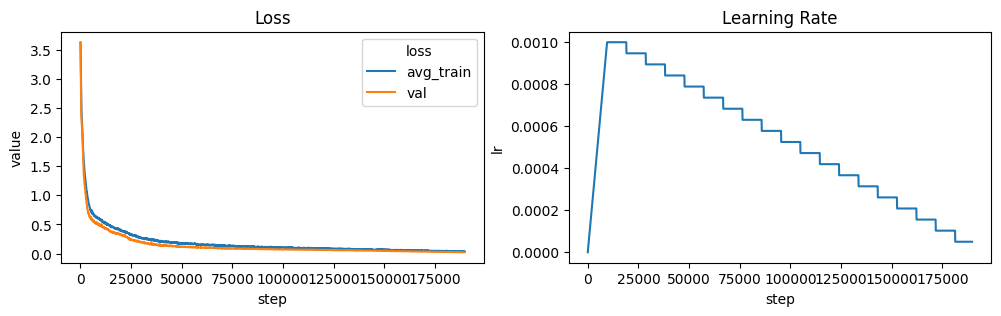

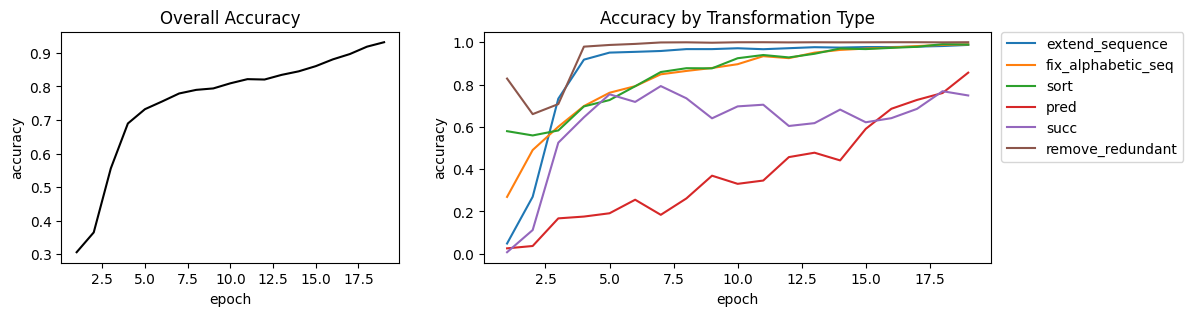

In [5]:
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

In [6]:
# if predictions are *NOT* saved as csv uncomment and run:
# keep_cols = [
#     'n_perm',
#     'problem',
#     'xq',
#     'transformation',
#     'query_length',
#     'yq',
#     'alphabet',
#     'study',
#     'pred'
# ]
# pred_data = analysis_utils.predict_dataset(val, model, max_length=50, keep_cols=keep_cols, alternative_rule_errors=True)
# # save data:
# pred_data.to_csv("prediction_data/pred_" + cp.model_path.replace("../models/","").replace(".pt","") + ".csv", index=False)

# otherwise:
pred_data = pd.read_csv("prediction_data/pred_MLC_d200kbasestudy3_nep20_best.csv")
# split into correct and incorrect samples
correct_pred = pred_data[pred_data["correct"]==True]
incorrect_pred = pred_data[pred_data["correct"]==False]

In [7]:
print(incorrect_pred.groupby("transformation")["alternate_rule"].value_counts())


transformation      alternate_rule
extend_sequence     na                 45
fix_alphabetic_seq  na                 11
                    pred               10
                    succ               10
pred                succ              477
                    na                117
sort                na                 25
                    succ                5
succ                pred              646
                    na                108
Name: count, dtype: int64


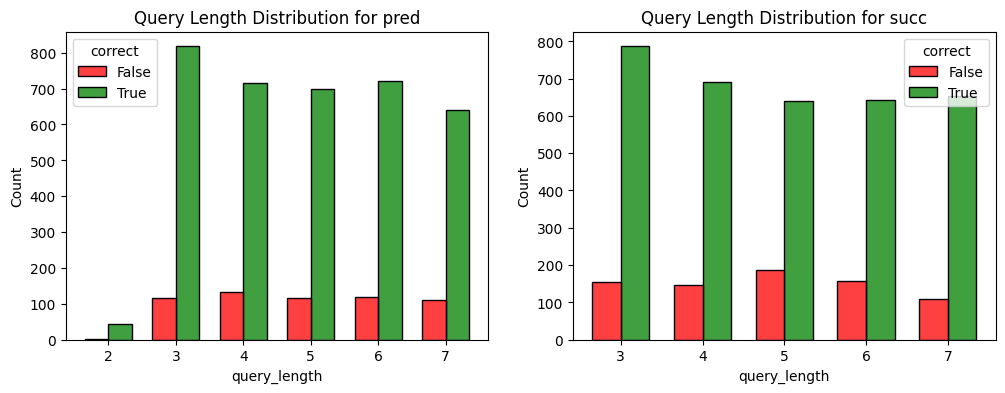

In [8]:
palette = {True: "green", False: "red"}
fig, ax = plt.subplots(1,2, figsize=(12,4))
_ = sns.histplot(pred_data[pred_data.transformation.isin(["pred"])], x="query_length", hue="correct", discrete=True, multiple="dodge", shrink=.7, palette=palette, ax=ax[0])
_ = ax[0].set_title("Query Length Distribution for pred")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["succ"])], x="query_length", hue="correct", discrete=True, multiple="dodge", shrink=.7, palette=palette, ax=ax[1])
_ = ax[1].set_title("Query Length Distribution for succ")

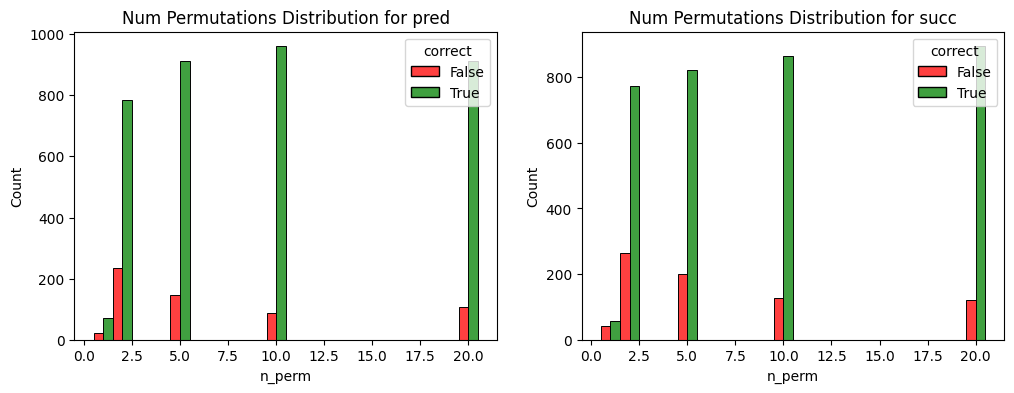

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
_ = sns.histplot(pred_data[pred_data.transformation.isin(["pred"])], x="n_perm", hue="correct", discrete=True, multiple="dodge", palette=palette, ax=ax[0])
_ = ax[0].set_title("Num Permutations Distribution for pred")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["succ"])], x="n_perm", hue="correct", discrete=True, multiple="dodge", palette=palette, ax=ax[1])
_ = ax[1].set_title("Num Permutations Distribution for succ")